<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum5/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 5 - Machine Learning Decision Tree


Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

# Memanggil dataset melalui gdrive
path = "gdrive/MyDrive/MachineLearning/Praktikum/data/week5/"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# 1. Gunakan dataset Iris untuk klasifikasi dengan target nama species

In [3]:
df = pd.read_csv(path + "Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# Buat model Decision Tree, bagi data menjadi 80% data training dan 20% data testing

In [5]:
# Membagi dataset
X = df.drop(['Species'], axis=1)
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
len(X_train), len(X_test)

(120, 30)

In [6]:
# Membangun model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

# Melakukan evaluasi model yang dibuat

In [7]:
# Evaluasi
y_pred = dt.predict(X_test)

# Define nama target menggunakan nilai unique dari variabel target y
datairis_classes = y.unique()

print("Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=datairis_classes
))

Akurasi: 100.0 %

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



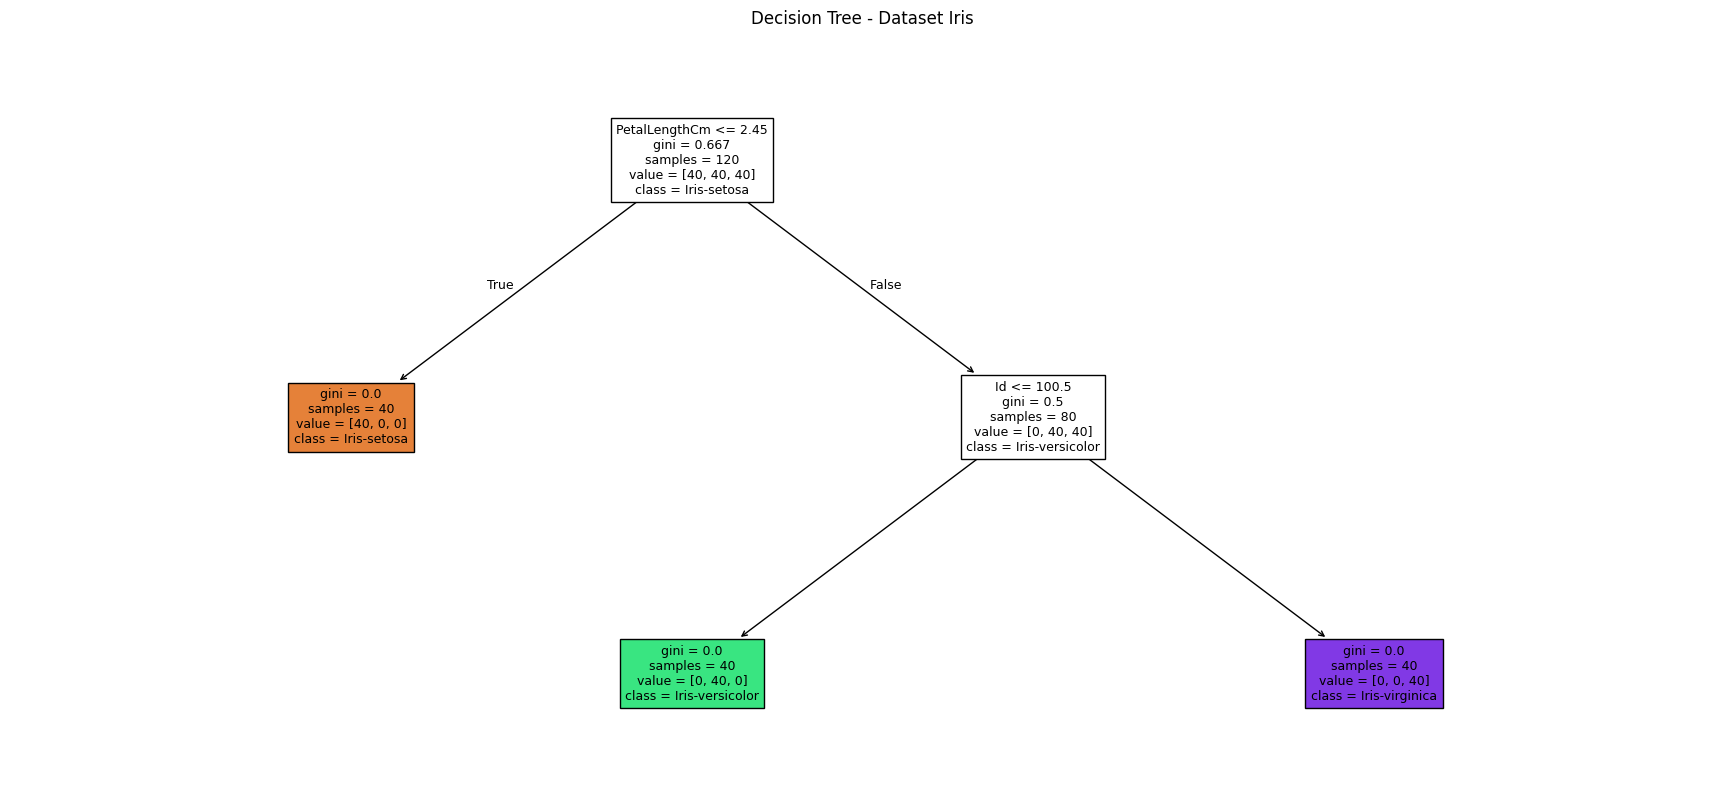

In [8]:
# Visualisasi model
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=y.unique(),
    filled=True,
    fontsize=9
)
plt.title("Decision Tree - Dataset Iris") # Updated title
plt.show()

# Menguji model menggunakan dataset testing

In [10]:
# Pengujian Model Menggunakan Data Testing
hasil = pd.DataFrame({
    "Data Aktual": y_test,
    "Data Prediksi": y_pred
})
print("\n=== Hasil Prediksi pada Data Testing ===")
print(hasil.head(10))


=== Hasil Prediksi pada Data Testing ===
         Data Aktual    Data Prediksi
38       Iris-setosa      Iris-setosa
127   Iris-virginica   Iris-virginica
57   Iris-versicolor  Iris-versicolor
93   Iris-versicolor  Iris-versicolor
42       Iris-setosa      Iris-setosa
56   Iris-versicolor  Iris-versicolor
22       Iris-setosa      Iris-setosa
20       Iris-setosa      Iris-setosa
147   Iris-virginica   Iris-virginica
84   Iris-versicolor  Iris-versicolor
